In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import stanza

plt.style.use('ggplot')

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import nltk

try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    print("Downloads concluídos com sucesso.")
except Exception as e:
    print(f"Erro no download: {e}")


Downloads concluídos com sucesso.


In [18]:
# Carregar dados de teste
df_test = pd.read_csv("../src/Tweets_EN_sentiment_test.csv")
df_train = pd.read_csv("../src/Tweets_EN_sentiment_train.csv")
# Informação básica sobre o dataset
print("Informação do dataset:")
print(df_test.info())

Informação do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2122 entries, 0 to 2121
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   2122 non-null   int64 
 1   text    2100 non-null   object
 2   class   2122 non-null   object
dtypes: int64(1), object(2)
memory usage: 49.9+ KB
None


In [15]:
stopwords = nltk.corpus.stopwords.words('english')
print("total words:", len(stopwords))
print(stopwords)

palavras_negacao = {'not', 'no', 'nor', 'against', "don't", "aren't", "couldn't",
                    "didn't", "doesn't", "hadn't", "hasn't", "haven't", "isn't",
                    "mightn't", "mustn't", "needn't", "shan't", "shouldn't",
                    "wasn't", "weren't", "won't", "wouldn't"}

stopwords_clean = [word for word in stopwords if word not in palavras_negacao]
print(stopwords_clean)


['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', 'd', 'did', 'didn', 'do', 'does', 'doesn', 'doing', 'don', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', 'has', 'hasn', 'have', 'haven', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', 'more', 'most', 'mustn', 'my', 'myself', 'needn', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', 'she', "she'd", "she'll", "she's", 'should', 'shouldn', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 

Remover URLs e menções (@utilizador) através de expressões regulares (Regex), pois não contêm valor de sentimento.

Filtrar caracteres não alfanuméricos, mantendo a pontuação expressiva como exclamações e emojis.

Preservar a capitalização (palavras em MAIÚSCULAS), dado que intensificam a polaridade nas métricas.

Filtrar stop words, garantindo que negações cruciais como "not" ou "no" são mantidas para não destruir o contexto.

Aplicar lematização para reduzir as palavras à sua forma base, facilitando o cruzamento com o dicionário do léxico.

STANZA - ele considera alguns stopwords relevantes como "but" etc
VADER - consegue ler emojis #utilizando a biblioteca emoji para transformar "I love this 😭" em "I love this :loudly_crying_face:"
TextBlob - não diferencia maiúsculas de minúsculas no seu cálculo de polaridade, mas o VADER usa isso como um multiplicador.

In [ ]:
def pre_processamento(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # 2. Manter letras, números, espaços e pontuação vital (! ? ')
    text = re.sub(r'[^\w\s\?\!\']', '', text)

    tokens = word_tokenize(text)

    tokens_limpos = []
    for w in tokens:
        if w.lower() not in stopwords_clean:
            lema = lemmatizer.lemmatize(w.lower())
            if w.isupper() and len(w) > 1:
                tokens_limpos.append(lema.upper())
            else:
                tokens_limpos.append(lema)
    return ' '.join(tokens_limpos)

# Aplicação segura aos dados
df_test['text_clean'] = df_test['text'].apply(pre_processamento)

Vamos criar uma versão do dataset sem números e comparar os resultados (Accuracy/F1-Score) com a versão que mantém os números.

Se decidirmos avançar com a remoção de números, basta alterar uma única linha na função de limpeza:

text = re.sub(r'[^a-zA-Z\s\?\!\']', '', text)

Se o seu dataset for desequilibrado (por exemplo, se 80% dos tweets totais forem positivos), estabelece-se a regra de que qualquer empate ou falta de sinal (zero) é classificado automaticamente como "pos". É uma heurística de negócio utilizada para maximizar a probabilidade estatística de acerto quando o algoritmo falha.

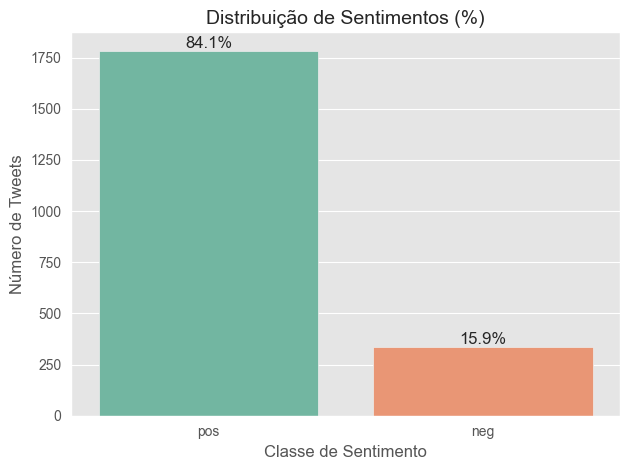

In [23]:
ax = sns.countplot(data=df_test, x='class', hue='class', palette='Set2', legend=False)

total = len(df_test['class'])

for p in ax.patches:
    percentagem = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentagem, (x, y), ha='center', va='bottom', fontsize=12)

plt.title('Distribuição de Sentimentos (%)', fontsize=14)
plt.xlabel('Classe de Sentimento', fontsize=12)
plt.ylabel('Número de Tweets', fontsize=12)
plt.tight_layout()
plt.show()

É deveras desequilibrado :)

Por isso vamos aplicar as seguintes regras -
VADER e TextBlob, Qualquer score contínuo de $0.0$ (neutro) é automaticamente classificado como "pos"
Stanza, Qualquer média de $1.0$ (neutro na escala Stanford) ou falha na leitura (texto vazio) é automaticamente absorvida pela classe "pos"

Cenários de limpeza distintos

Cenário A (Baseline), Limpeza segura que mantém pontuação expressiva, números, capitalização e remove apenas as stopwords irrelevantes.

Cenário B (Sem Números), Retira puramente os dígitos para testar o nível de ruído provocado por gírias e classificações numéricas.

Cenário C (Full Context), Não remove nenhuma stopword, preservando a sintaxe absoluta da frase para testar se os modelos neurais (Stanza) beneficiam da gramática completa.

In [30]:
lemmatizer = WordNetLemmatizer()

#Cenário A
def prep_baseline(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'USER|URL', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s\?\!\']', '', text)

    tokens = word_tokenize(text)
    tokens_limpos = []
    for w in tokens:
        if w.lower() not in stopwords_clean:
            lema = lemmatizer.lemmatize(w.lower())
            if w.isupper() and len(w) > 1:
                tokens_limpos.append(lema.upper())
            else:
                tokens_limpos.append(lema)
    return ' '.join(tokens_limpos)

# Cenário B
def prep_sem_numeros(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'USER|URL', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s\?\!\']', '', text)
    tokens = word_tokenize(text)
    tokens_limpos = []
    for w in tokens:
        # Mantém a lógica de filtragem de stopwords do Baseline
        if w.lower() not in stopwords_clean:
            lema = lemmatizer.lemmatize(w.lower())
            if w.isupper() and len(w) > 1:
                tokens_limpos.append(lema.upper())
            else:
                tokens_limpos.append(lema)

    return ' '.join(tokens_limpos)

# Atualização do Mapeamento no Dataset
df_test['text_sem_numeros'] = df_test['text'].apply(prep_sem_numeros)

print("Cenário B processado: Stopwords removidas e Números excluídos.")

# Cenário C
def prep_full_context(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'USER|URL', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s\?\!\']', '', text)

    tokens = word_tokenize(text)
    tokens_limpos = []
    for w in tokens:
        lema = lemmatizer.lemmatize(w.lower())
        if w.isupper() and len(w) > 1:
            tokens_limpos.append(lema.upper())
        else:
            tokens_limpos.append(lema)
    return ' '.join(tokens_limpos)

# 5. Mapeamento Matricial ao Dataset
df_test['text_baseline'] = df_test['text'].apply(prep_baseline)
df_test['text_sem_numeros'] = df_test['text'].apply(prep_sem_numeros)
df_test['text_full_context'] = df_test['text'].apply(prep_full_context)